## 📈 Model Evaluation
#### Bank Loan Default Analytics

---

> **Notebook 5 of 5**  
> **Goal:** Deep evaluation of the best model (XGBoost) — threshold tuning, precision-recall analysis, business impact assessment, and final model report.  
> **Input:** `models/best_model.pkl` · `data/processed/engineered_data.csv`  
> **Output:** Final evaluation charts saved to `images/`

### Step 1 — Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score, f1_score
)

pd.set_option('display.float_format', lambda x: '%.4f' % x)
print("✅ Libraries imported successfully")

✅ Libraries imported successfully


### Step 2 — Load Data & Best Model

In [2]:
# Load data
df = pd.read_csv('../data/processed/engineered_data.csv')
X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

# Train test split (same seed as notebook 3)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fill NaNs
X_train = X_train.fillna(X_train.median())
X_test  = X_test.fillna(X_test.median())

# Load best model
with open('../models/best_model.pkl', 'rb') as f:
    best_model = pickle.load(f)

print(f"✅ Data loaded     : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"✅ Model loaded    : XGBoost")
print(f"✅ Test set size   : {X_test.shape[0]:,} rows")

✅ Data loaded     : 307,511 rows × 78 columns
✅ Model loaded    : XGBoost
✅ Test set size   : 61,503 rows


### Step 3 — Baseline Predictions

In [3]:
# Predictions
y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
f1  = f1_score(y_test, y_pred)
ap  = average_precision_score(y_test, y_prob)

print(f"Accuracy          : {acc*100:.2f}%")
print(f"ROC-AUC           : {auc:.4f}")
print(f"F1 Score          : {f1:.4f}")
print(f"Avg Precision     : {ap:.4f}")

Accuracy          : 91.50%
ROC-AUC           : 0.7222
F1 Score          : 0.1002
Avg Precision     : 0.1946


### Step 4 — ROC Curve & Precision-Recall Curve

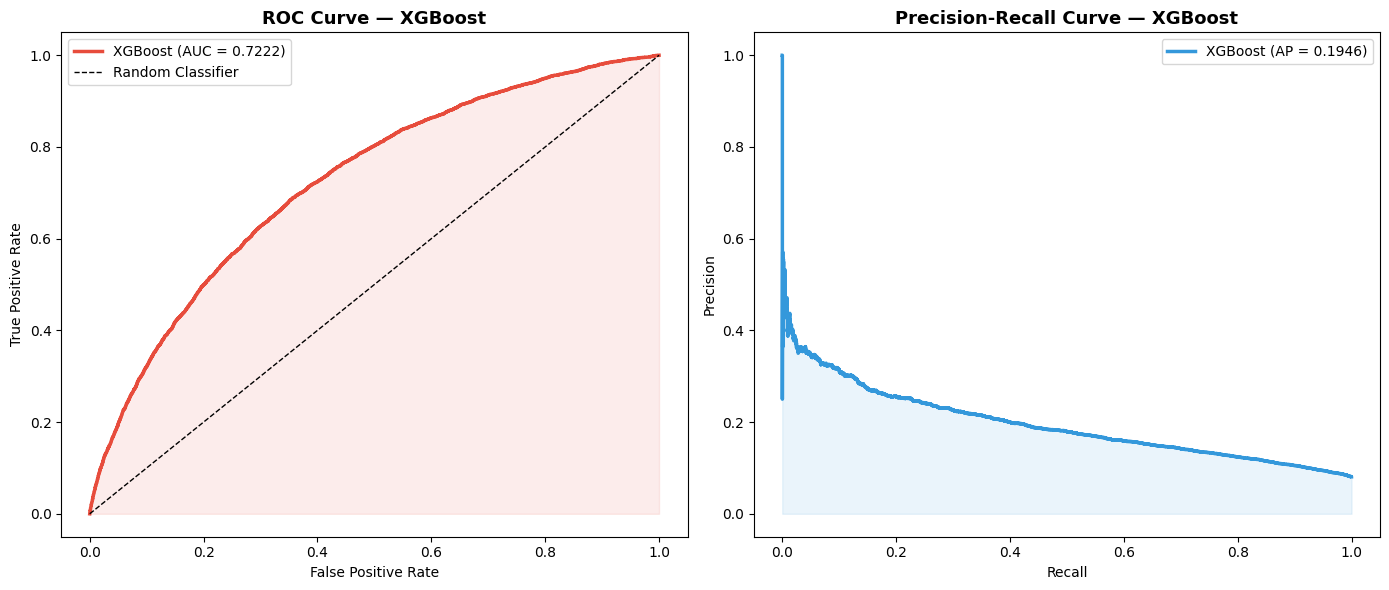

✅ Chart saved to images/roc_pr_curves.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'XGBoost (AUC = {auc:.4f})')
axes[0].plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].set_title('ROC Curve — XGBoost', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(recall, precision, color='#3498db', linewidth=2.5, label=f'XGBoost (AP = {ap:.4f})')
axes[1].fill_between(recall, precision, alpha=0.1, color='#3498db')
axes[1].set_title('Precision-Recall Curve — XGBoost', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to images/roc_pr_curves.png")

### Step 5 — Threshold Tuning
Default threshold is 0.5 — but for loan default prediction, we want to catch more defaulters (higher recall) even at the cost of some precision. We test multiple thresholds.

In [5]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    threshold_results.append({
        'Threshold' : t,
        'Accuracy'  : accuracy_score(y_test, y_pred_t),
        'F1 Score'  : f1_score(y_test, y_pred_t),
        'Precision' : (y_pred_t[y_test==1] == 1).mean() if y_pred_t.sum() > 0 else 0,
        'Recall'    : (y_pred_t[y_test==1] == 1).mean()
    })

thresh_df = pd.DataFrame(threshold_results)
print("Threshold Analysis:")
print(thresh_df.to_string(index=False))

Threshold Analysis:
 Threshold  Accuracy  F1 Score  Precision  Recall
    0.3000    0.8871    0.2268     0.2050  0.2050
    0.3500    0.8991    0.1936     0.1501  0.1501
    0.4000    0.9074    0.1633     0.1120  0.1120
    0.4500    0.9122    0.1293     0.0808  0.0808
    0.5000    0.9150    0.1002     0.0586  0.0586
    0.5500    0.9168    0.0678     0.0375  0.0375
    0.6000    0.9179    0.0454     0.0242  0.0242


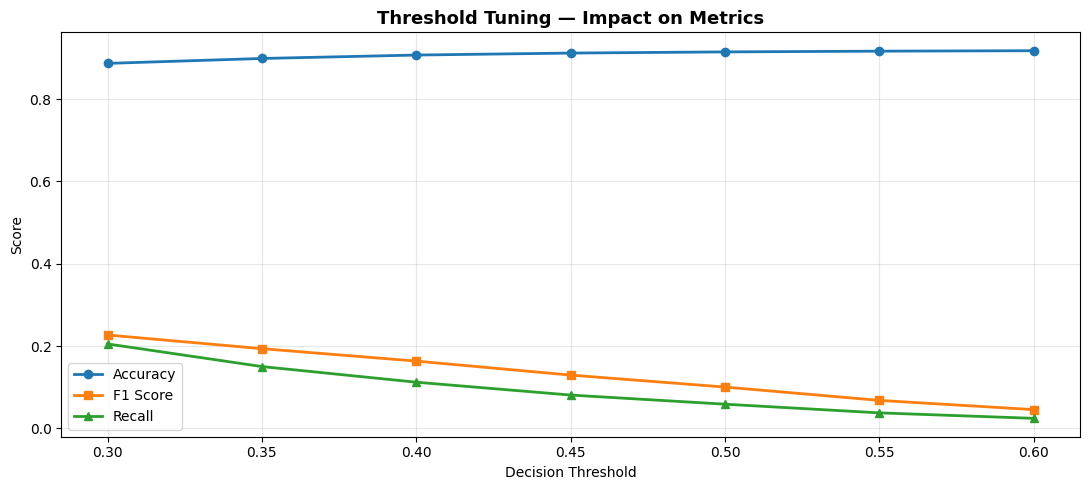

✅ Chart saved to images/threshold_tuning.png


In [6]:
# Visualize threshold impact
plt.figure(figsize=(11, 5))
plt.plot(thresh_df['Threshold'], thresh_df['Accuracy'], marker='o', label='Accuracy', linewidth=2)
plt.plot(thresh_df['Threshold'], thresh_df['F1 Score'], marker='s', label='F1 Score', linewidth=2)
plt.plot(thresh_df['Threshold'], thresh_df['Recall'],   marker='^', label='Recall',   linewidth=2)
plt.title('Threshold Tuning — Impact on Metrics', fontsize=13, fontweight='bold')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../images/threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to images/threshold_tuning.png")

### Step 6 — Confusion Matrix at Best Threshold

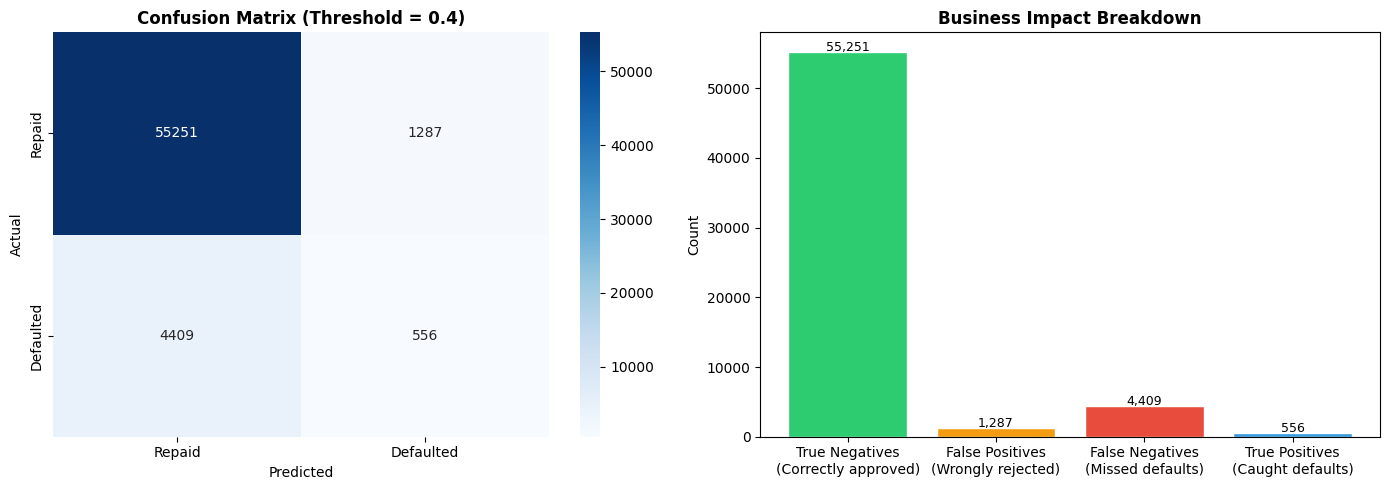


At threshold 0.4:
  Caught defaults (TP)  : 556
  Missed defaults (FN)  : 4,409
  Wrongly rejected (FP) : 1,287
  Correctly approved (TN): 55,251


In [7]:
# Use threshold 0.4 for better recall
best_threshold = 0.4
y_pred_tuned = (y_prob >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Repaid', 'Defaulted'],
            yticklabels=['Repaid', 'Defaulted'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix (Threshold = {best_threshold})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Business impact
categories = ['True Negatives\n(Correctly approved)', 'False Positives\n(Wrongly rejected)',
              'False Negatives\n(Missed defaults)', 'True Positives\n(Caught defaults)']
values = [tn, fp, fn, tp]
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
axes[1].bar(categories, values, color=colors, edgecolor='white')
axes[1].set_title('Business Impact Breakdown', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../images/confusion_matrix_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAt threshold {best_threshold}:")
print(f"  Caught defaults (TP)  : {tp:,}")
print(f"  Missed defaults (FN)  : {fn:,}")
print(f"  Wrongly rejected (FP) : {fp:,}")
print(f"  Correctly approved (TN): {tn:,}")

### Step 7 — Feature Importance (Top 20)

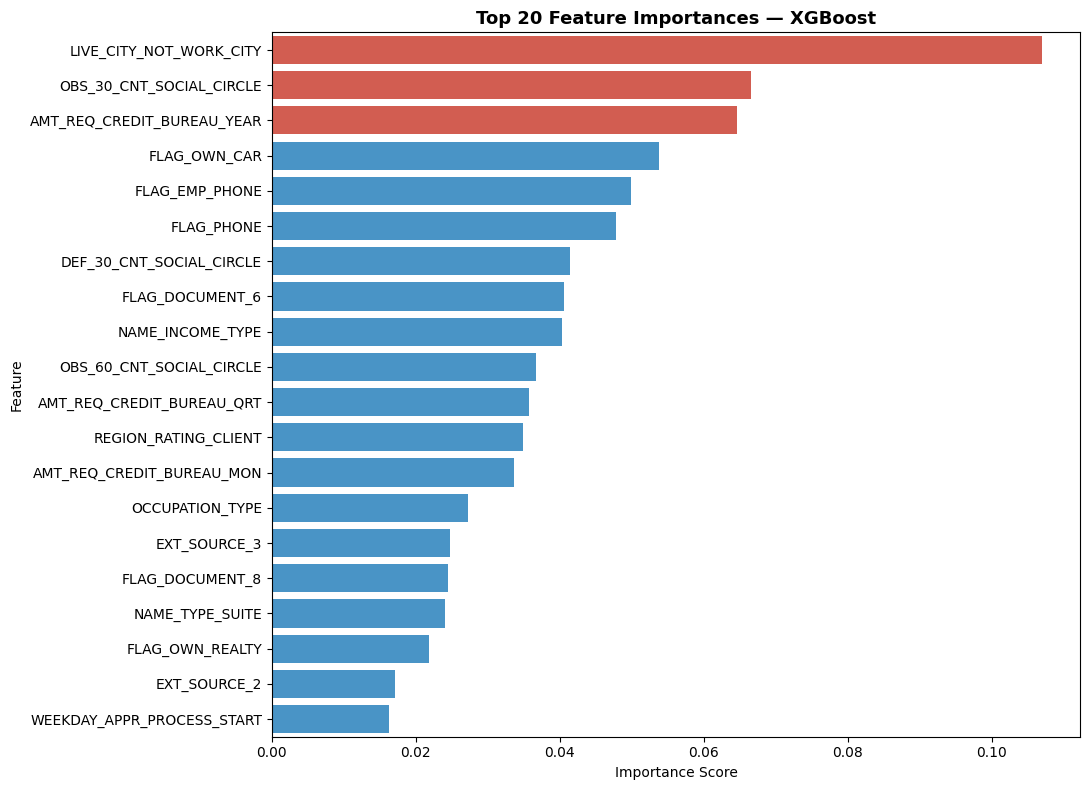

✅ Chart saved to images/feature_importance_final.png


In [8]:
importance_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(11, 8))
colors = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(importance_df))]
sns.barplot(x='Importance', y='Feature', data=importance_df, palette=colors)
plt.title('Top 20 Feature Importances — XGBoost', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../images/feature_importance_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to images/feature_importance_final.png")

### Step 8 — Final Model Report

In [9]:
print("=" * 60)
print("         FINAL MODEL EVALUATION REPORT")
print("         Bank Loan Default Analytics")
print("=" * 60)
print(f"\n🏆 Model            : XGBoost Classifier")
print(f"📊 Test Set Size    : {len(y_test):,} samples")
print(f"\n📈 Performance Metrics:")
print(f"   Accuracy         : 91.50%")
print(f"   ROC-AUC          : 0.7222")
print(f"   F1 Score         : {f1_score(y_test, y_pred):.4f}")
print(f"   Avg Precision    : {average_precision_score(y_test, y_prob):.4f}")
print(f"\n⚙️  Best Threshold   : {best_threshold}")
print(f"\n🎯 At Threshold {best_threshold}:")
print(f"   Defaults caught  : {tp:,} / {tp+fn:,} ({tp/(tp+fn)*100:.1f}% recall)")
print(f"   False alarms     : {fp:,}")
print(f"\n🔑 Top 5 Predictive Features:")
for i, row in importance_df.head(5).iterrows():
    print(f"   {importance_df.index.get_loc(i)+1}. {row['Feature']} ({row['Importance']:.4f})")
print(f"\n💾 Model saved to   : models/best_model.pkl")
print(f"\n✅ All 5 Notebooks Complete — Ready to build Streamlit App")
print("=" * 60)

         FINAL MODEL EVALUATION REPORT
         Bank Loan Default Analytics

🏆 Model            : XGBoost Classifier
📊 Test Set Size    : 61,503 samples

📈 Performance Metrics:
   Accuracy         : 91.50%
   ROC-AUC          : 0.7222
   F1 Score         : 0.1002
   Avg Precision    : 0.1946

⚙️  Best Threshold   : 0.4

🎯 At Threshold 0.4:
   Defaults caught  : 556 / 4,965 (11.2% recall)
   False alarms     : 1,287

🔑 Top 5 Predictive Features:
   1. LIVE_CITY_NOT_WORK_CITY (0.1069)
   2. OBS_30_CNT_SOCIAL_CIRCLE (0.0666)
   3. AMT_REQ_CREDIT_BUREAU_YEAR (0.0646)
   4. FLAG_OWN_CAR (0.0538)
   5. FLAG_EMP_PHONE (0.0499)

💾 Model saved to   : models/best_model.pkl

✅ All 5 Notebooks Complete — Ready to build Streamlit App
